# CEH GEAR-Hourly: Zarr via Python + Xarray

**Launch this notebook:**

<a href="https://colab.research.google.com/github/NERC-CEH/fdri-gridded-notebooks/blob/main/gear_zarr_python.ipynb" target="_blank">![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)</a>
<a href="https://mybinder.org/v2/gh/NERC-CEH/fdri-gridded-notebooks/HEAD?labpath=gear_zarr_python.ipynb">![Binder](https://mybinder.org/badge_logo.svg)</a>
---

## What this notebook does

This notebook explores **GEAR-Hourly** (Gridded Estimates of Areal Rainfall — Hourly), a gridded rainfall dataset for Great Britain produced as part of the [FDRI (Floods and Droughts Research Infrastructure)](https://fdri.org.uk) project. 

Simple examples are shown for exploring and working with the dataset, which can be generalised to any gridded dataset stored on S3 storage, a storage medium that is becoming increasingly common for large gridded datasets. Datasets on S3 storage are typically stored in the Zarr format. However if you are familiar with working with NetCDF files with Xarray, this will be largely transparent to you with respect to the commands you can use to view and analyse the dataset.

**We will:**
1. Show how to open a dataset stored in Zarr format 
2. Show how to extract and plot a time series at a single location
3. Show how to plot a map of rainfall at a single time step
4. Provide resources for further learning and exploration

**Data store:**
The data is currently publicly available as a trial through JASMIN object storage at the following URL:
```
https://fdri-o.s3-ext.jc.rl.ac.uk/gearhrly/gearhrly_15day_100km_chunks.zarr
```

---

## 0. Setup

### Google Colab

If running on Google Colab, a few extra packages need to be installed for the notebook to run properly:

In [1]:
# Install if needed (safe to run even if already installed)
%pip install -q zarr netcdf4 cartopy xoak s3fs

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-expr 1.1.1 requires dask==2024.5.1, but you have dask 2024.5.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


You may see a message like "ERROR: pip's dependency resolver does not currently take into account all the packages that are installed...", but that's fine, the packages we need still get installed.

Import the packages we need:

In [58]:
import xarray as xr
import matplotlib.pyplot as plt
from dask.diagnostics import ProgressBar
import xoak
import s3fs

print(f"xarray  version: {xr.__version__}")

xarray  version: 2026.2.0


---
## 1. Open the Zarr store

`xr.open_zarr()` connects to the store over HTTPS without downloading any data yet.  

For publically available data such as this, we do not need any credentials, and instead pass anon=True which means 'access the data as an anonymous user'.

In [59]:
ds = xr.open_zarr(
    "s3://gearhrly/gearhrly_15day_100km_chunks.zarr",
    storage_options={
        "anon": True,
        "endpoint_url": "https://fdri-o.s3-ext.jc.rl.ac.uk/"
    },
    consolidated=True
)

In [4]:
ds

<xarray.Dataset> Size: 5TB
Dimensions:          (time: 236688, y: 1251, x: 701, bnds: 2)
Coordinates:
  * time             (time) datetime64[ns] 2MB 1990-01-01 ... 2016-12-31T23:0...
  * y                (y) float64 10kB 1.25e+06 1.249e+06 1.248e+06 ... 1e+03 0.0
  * x                (x) float64 6kB 0.0 1e+03 2e+03 ... 6.98e+05 6.99e+05 7e+05
    lat              (y, x) float64 7MB dask.array<chunksize=(100, 100), meta=np.ndarray>
    lon              (y, x) float64 7MB dask.array<chunksize=(100, 100), meta=np.ndarray>
    time_bnds        (time, bnds) datetime64[ns] 4MB dask.array<chunksize=(360, 2), meta=np.ndarray>
    x_bnds           (x, bnds) float64 11kB dask.array<chunksize=(100, 2), meta=np.ndarray>
    y_bnds           (y, bnds) float64 20kB dask.array<chunksize=(100, 2), meta=np.ndarray>
    crs              int16 2B ...
Dimensions without coordinates: bnds
Data variables:
    min_dist         (time, y, x) float64 2TB dask.array<chunksize=(360, 100, 100), meta=np.ndarray>
    rainfall_amount  (time, y, x) float64 2TB dask.array<chunksize=(360, 100, 100), meta=np.ndarray>
    stat_disag       (time, y, x) float64 2TB dask.array<chunksize=(360, 100, 100), meta=np.ndarray>
Attributes: (12/29)
    Conventions:                   CF-1.6
    acknowledgement:               This research forms part of the SINATRA pr...
    cdm_data_type:                 Grid
    contributor_name:              Lewis, E., Quinn, N., Blenkinsop, S., Fowl...
    creator_email:                 enquiries@ceh.ac.uk
    creator_institution:           UK Centre for Ecology & Hydrology (UKCEH)
    ...                            ...
    standard_name_vocabulary:      CF Standard Name Table v70, http://cfconve...
    summary:                       The CEH-GEAR1hr-v2 dataset contains 1-km g...
    time_coverage_duration:        P27Y
    time_coverage_resolution:      P1H
    title:                         Gridded estimates of hourly areal rainfall...
    version:                       v2

Size of dataset in TeraBytes:

In [5]:
ds.nbytes/1E12

4.98155043749

The variables in the dataset are split into those that describe the coordinates, and those of the main data. We can see the three main data variables: 'min_dist', 'rainfall_amount' and 'stat_disag', you can click the page icon at the end of each variable's row to find out a little more about each.

The names in brackets next to the variable names (the second column of information) show you the dimensions that each variable is on. Here, all our data variables are on a 3D grid of time, y and x.

You can see in the Coordinates section that we have other coordinates besides those for the time, y and x dimensions. The lat and lon variables tell you the latitude and longitude conversion for each x,y gridpoint and the 'xxx_bnds' variables tell you the extent/valid range of each datapoint. So for example a gridpoint of (6000,6000) on a grid with a resolution of (1000,1000) would have extents/boundaries of (5500,6500) for both x and y, describing the extent of the gridbox this gridpoint represents. The same concept can be extended to the time-dimension too.

---
## 2. Time series at a single location

Xarray allows you to select out a location using the dataset coordinates, instead of having to worry about indexing. 

You can use any of the coordinate variables in the dataset, not just those that the data is actually on. For the UKCEH-GEAR dataset it is on the x/y coordinates of the OS National Grid, but you may prefer to select out points based on longitude and latitude, for which a further example is available. All FDRI datasets, and in fact all datasets that adhere to the CF-Conventions, will also have longitude and latitude coordinates pre-calculated if the data is not already on a lon/lat grid.  Look at the 'Coordinates' section in the view of the dataset metadata in Section 1 to see what coordinates are available.

#### Using x/y coordinates

We can see from the metadata view in Section 1 that the data variables are on an x/y grid. We can use these x/y coordinates to select out a data point to view.

In [6]:
ds['x']

<xarray.DataArray 'x' (x: 701)> Size: 6kB
array([     0.,   1000.,   2000., ..., 698000., 699000., 700000.])
Coordinates:
  * x        (x) float64 6kB 0.0 1e+03 2e+03 3e+03 ... 6.98e+05 6.99e+05 7e+05
    crs      int16 2B ...
Attributes:
    bounds:         x_bnds
    long_name:      easting - OSGB36 grid reference
    point_spacing:  even
    standard_name:  projection_x_coordinate
    units:          m

In [7]:
ds['y']

<xarray.DataArray 'y' (y: 1251)> Size: 10kB
array([1.250e+06, 1.249e+06, 1.248e+06, ..., 2.000e+03, 1.000e+03, 0.000e+00])
Coordinates:
  * y        (y) float64 10kB 1.25e+06 1.249e+06 1.248e+06 ... 2e+03 1e+03 0.0
    crs      int16 2B ...
Attributes:
    bounds:         y_bnds
    long_name:      northing - OSGB36 grid reference
    point_spacing:  even
    standard_name:  projection_y_coordinate
    units:          m

In [61]:
# Choose a location — e.g. Edinburgh, Scotland
# Adjust to any point within the dataset's extent
target_x = 500000 
target_y = 200000

# Choose a time period of interest
start = '1999-09-01'
end = '2000-04-01'

# The variable name — see the 'Data variables' of the view of the dataset metadata in Section 1 
var_name = "rainfall_amount"

# Select the nearest grid cell
# The coordinate names depend on the store — common names: longitude/latitude, lon/lat, x/y
timeslice = ds[var_name].sel(time=slice(start, end))
point = timeslice.sel(x=target_x, y=target_y, method='nearest')

# Load the time series into memory, and persist it!
with ProgressBar():
    ts = point.compute()

[########################################] | 100% Completed | 2.42 sms


In [62]:
ts

<xarray.DataArray 'rainfall_amount' (time: 5136)> Size: 41kB
array([0. , 0. , 0. , ..., 0.7, 0.3, 0.3])
Coordinates:
  * time     (time) datetime64[ns] 41kB 1999-09-01 ... 2000-04-01T23:00:00
    crs      int16 2B -32767
    lat      float64 8B 51.69
    lon      float64 8B -0.5547
    x        float64 8B 5e+05
    y        float64 8B 2e+05
Attributes:
    grid_mapping:   crs
    long_name:      Gridded estimates of hourly rainfall
    standard_name:  rainfall_amount
    units:          kg m-2
    valid_max:      500.0
    valid_min:      0.0

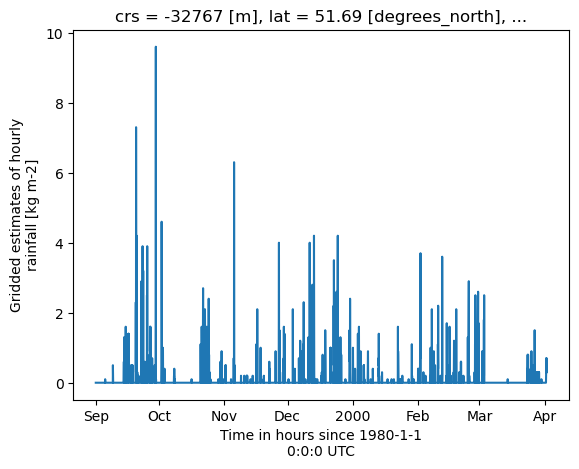

In [63]:
ts.plot()

Or you can customise the plot using matplotlib, the standard python plotting library, but this requires a few more lines of code to setup the plot and tweak the things you might want to:

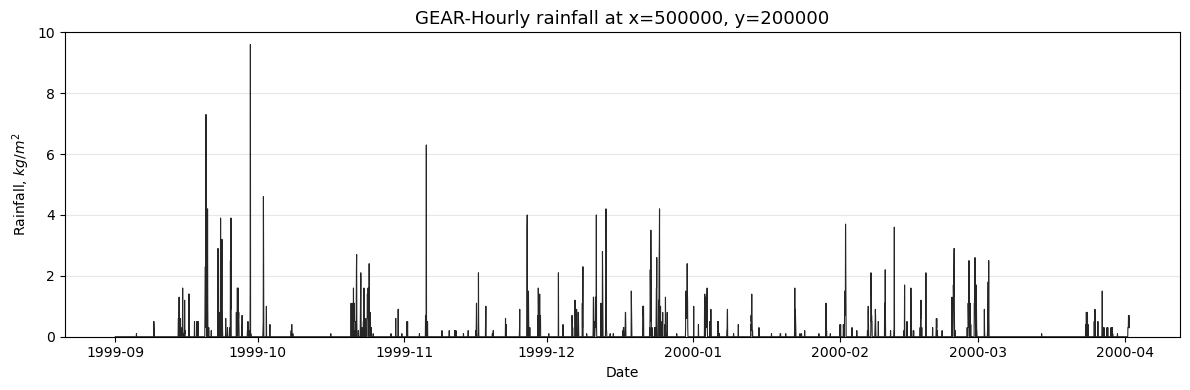

In [66]:
fig, ax = plt.subplots(figsize=(12, 4)) # customize the size of the plot

# plot the data on the axes (ax) we just created using ax.plot(x values, y values, customisations...)
# customize the line colour, width and transparency (alpha)
ax.plot(ts.time, ts.values, color="black", linewidth=0.8, alpha=0.85)

ax.set_title(f"GEAR-Hourly rainfall at x={target_x}, y={target_y}", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Rainfall, " + r'$kg/m^2$')
ax.set_ylim([0, 10])
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

---
## 3. Map at a single time step

Select one time step and load the full spatial grid. xarray's `.plot()` creates a quick map from any 2-D DataArray. As with selection of x/y coordinates, you can use the time coordinate values to select, instead of having to worry about indexing.

In [30]:
# Select a time step
# You can use sel(time="YYYY-MM-DD") for date-based selection
t = "2000-01-01 00:00"
var_name = 'rainfall_amount'
hourmap = ds[var_name].sel(time=t)

with ProgressBar():
    hourmap = hourmap.compute()

[########################################] | 100% Completed | 7.19 ss


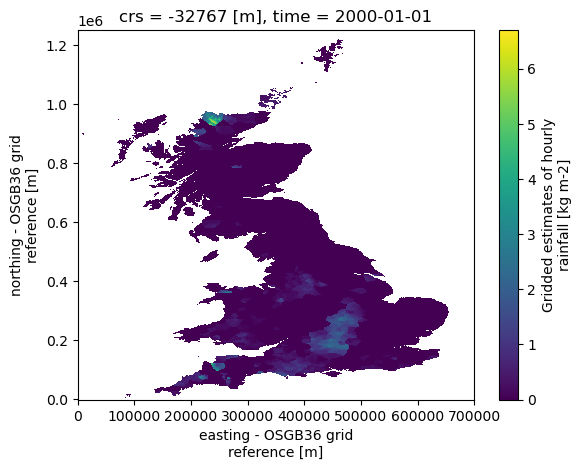

In [31]:
hourmap.plot()

But as before we can also customise the plot. For maps, the cartopy library is generally best.

In [32]:
import cartopy.crs as ccrs # the set of map projections cartopy supports
import cartopy as cp # the full cartopy package

Passing the projection 'key-word argument' to the plotting function tells the plotting library to invoke cartopy to draw the plot using a given map projection. Here we are using the 'OSGB' map projection (a cartesian grid, in other words a flat plane approximation that ignores the curvature of the earth) which a lot of UK hydrological data will be on. For any data that is on a 'lon/lat' grid instead of an 'x/y' grid, the ccrs.PlateCarree() projection is a better option.

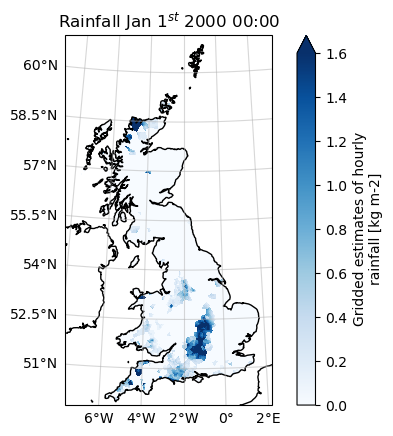

In [35]:
plot1 = hourmap.plot.pcolormesh(cmap='Blues', robust=True, subplot_kws=dict(projection=ccrs.OSGB())) # create the initial plot
plt.title(r'Rainfall Jan $1^{st}$ 2000 00:00')
plot1.axes.coastlines() # add coastlines
gl = plot1.axes.gridlines(draw_labels=True, alpha=0.5) # add gridlines. The alpha parameter is the transparency between 0 and 1. 
gl.top_labels = False
gl.right_labels = False # remove the top and right gridlines labels to make the plot look nicer

---
## 4. Catchment extraction

We can also extract out a particular river catchment to look at, instead of the whole UK.

To do this we need the **geopandas** library, a shapefile to use for the subsetting, and some extra code utilities.

Fetch code utilities:

In [36]:
!wget https://github.com/NERC-CEH/UKCEH_Summer_School/raw/refs/heads/main/Workshop_3/utils.py

--2026-04-10 17:58:48--  https://github.com/NERC-CEH/UKCEH_Summer_School/raw/refs/heads/main/Workshop_3/utils.py
Resolving github.com (github.com)... 20.26.156.215
Connecting to github.com (github.com)|20.26.156.215|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/NERC-CEH/UKCEH_Summer_School/refs/heads/main/Workshop_3/utils.py [following]
--2026-04-10 17:58:49--  https://raw.githubusercontent.com/NERC-CEH/UKCEH_Summer_School/refs/heads/main/Workshop_3/utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20987 (20K) [text/plain]
Saving to: ‘utils.py’

utils.py            100%[===================>]  20.50K  --.-KB/s    in 0s      

2026-04-10 17:58:49 (111 MB/s) - ‘utils.py’ saved [20987/2098

In [46]:
from utils import *

Load geopandas

In [37]:
import geopandas as gpd

Read in the shapefile from the cloud (publically available for use):

In [42]:
sfname = 's3://example-data/gb_catchments.zip'
fs_shp = s3fs.S3FileSystem(anon=True, endpoint_url="https://fdri-o.s3-ext.jc.rl.ac.uk")
sfile = gpd.read_file(fs_shp.open(sfname))

sfile

,OBJECTID,ID_STRING,ID,SHAPE_AREA,SHAPE_LEN,geometry
0,227,18010,18010.0,0.0,0.0,"POLYGON ((271449.998 695224.998, 271400 695224..."
1,244,21014,21014.0,0.0,0.0,"POLYGON ((310900.002 628474.999, 311150.002 62..."
2,245,21015,21015.0,0.0,0.0,"POLYGON ((356475.002 638850.002, 356349.999 63..."
3,247,21017,21017.0,0.0,0.0,"POLYGON ((323424.998 613149.998, 323375 613100..."
4,269,22004,22004.0,0.0,0.0,"POLYGON ((421150.002 612925, 421225.001 612850..."
...,...,...,...,...,...,...
1888,174,21003,21003.0,0.0,0.0,"POLYGON ((325775.002 640050, 325775.002 640000..."
1889,187,19021,19021.0,0.0,0.0,"POLYGON ((333800.001 667825.002, 333900.002 66..."
1890,197,20806,20806.0,0.0,0.0,"POLYGON ((363849.998 677374.998, 364024.998 67..."
1891,204,17004,17004.0,0.0,0.0,"POLYGON ((333000 699774.998, 333100.001 699774..."


With geopandas each shape in the shapefile is represented by a row in the table, and the metadata associated with each shape by the columns. The geometry column contains the vector information that describes the actual shape.

We can use the subsetting script to cut out a piece of our dataset according to one or more shapes in the shapefile.

This is the convenience function I've developed to ease the process. Put a question mark after a given function, to see more information about it:

In [47]:
catchment_subset_shapefile?

Signature:
catchment_subset_shapefile(
    data=None,
    datafile=None,
    multifile=0,
    sfname=None,
    endpoint=None,
    xname='x',
    yname='y',
    IDname=None,
    IDs=None,
    drop=0,
)
Docstring:
Function to subset an xarray dataarray or dataset, or netcdf dataset, to selected shapes from 
a shapefile. Returns an xarray dataset with of the same shape as the input
datafile but with the data outside the selected shapes
set to nans. Also returns the shapes so these can be plotted.

data:     An xarray DataArray or DataSet
datafile: The filename of the netcdf file to subset. Multiple files can be selected with * etc.
          If this is the case multifile should be set to 1. Defaults to 0.
sfname:   The filepath of the shapefile
endpoint: Used if sfname is an s3 path. The endpoint_url for the s3 storage system being used. 
IDname:   The name of the catgeory to search over for selecting shapes to subset to (e.g. 'RIVER')
IDs:      The values of the category to select (e.g. 

We can use any of the columns to identify which shapes we'd like to use to subset our data. In this case, the only helpful one is the 'ID' column, which refers to the ID of a given catchment in the NRFA database. These can be [explored here](https://nrfa.ceh.ac.uk/data/search).

Catchment ID 39001 is the 'Thames to Kingston' catchment, which is the entire non-tidal Thames basin.

In [50]:
cat39001data = catchment_subset_shapefile(data=hourmap, sfname=sfname, 
                                          endpoint="https://fdri-o.s3-ext.jc.rl.ac.uk", 
                                          IDname='ID_STRING', IDs=['39001'], drop=1)

Found: 39001
Adding mask to xarray


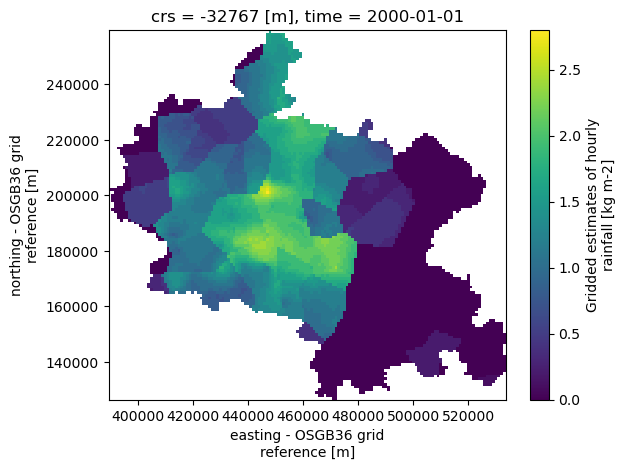

In [51]:
cat39001data.plot()

Or a better plot, where I've chose to highlight the Chess catchment too:

Text(0.5, 1.0, 'Rain at 2000-01-01 00:00')

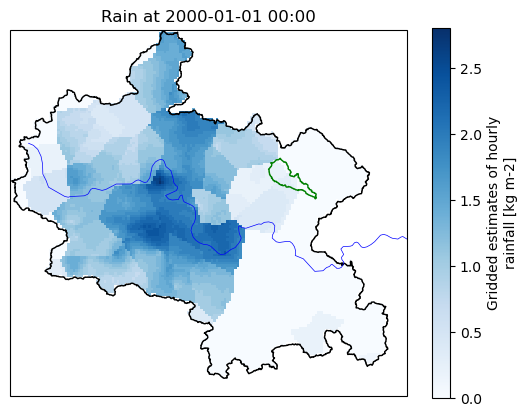

In [55]:
cat39001 = sfile.where(sfile['ID_STRING']=='39001').dropna() # Thames to Kingston
cat39088 = sfile.where(sfile['ID_STRING']=='39088').dropna() # Chess to Rickmansworth

gbax = plt.axes(projection=cp.crs.OSGB()) # create the (geo) axes for the plot
cat39001.plot(ax=gbax, facecolor='None', edgecolor='black', zorder=1) # plot the catchment shapefile, transparently (facecolor='None') and on top of the data (zorder=1)
cat39088.plot(ax=gbax, facecolor='None', edgecolor='green', zorder=1) # plot the catchment shapefile, transparently (facecolor='None') and on top of the data (zorder=1)
rivers = cp.feature.NaturalEarthFeature('physical', 'rivers_lake_centerlines', '10m', edgecolor='blue', facecolor='none', lw=0.5) # add in the river thames from a public data source (Natural Earth)
gbax.add_feature(rivers)
cat39001data.plot(ax=gbax, cmap='Blues', zorder=0) # add the data we extracted earlier to the plot
plt.title("Rain at 2000-01-01 00:00")

---
### Some other commands to try

| Task | Code |
|------|------|
| Select by date | `ds[var].sel(time="2015-01-01 06:00")` |
| Select a date range | `ds[var].sel(time=slice("2015-01-01", "2015-01-31"))` |
| Monthly mean | `ds[var].resample(time="1ME").mean()` |
| Spatial mean over GB | `ds[var].mean(dim=["y", "x"])` |
| Save to NetCDF | `ds.to_netcdf("output.nc")` |

where 'ds[var]' can be replaced with whatever xarray DataArray/DataSet you are working with.

### Further resources

<details>
  <summary>More details on lazy-loading and persistence when working with Zarr vs NetCDF</summary>
  
The one difference to be aware of is data *persistence* in memory, which needs to be handled explicitly for performant access. Xarray lazy-loads data, which means it doesn't *actually* load the data into memory until it absolutely has to be. So you may run some code that computes the mean of the dataset (e.g. dmean = ds['variable'].mean(dim='time')), but the computation will only actually be carried out when you want to see the result of this calculation, e.g. through a plot or print statement, or saving to disk. This is standard behaviour whether you are loading in NetCDF from a local disk or reading in a remote Zarr datastore. However, in the latter case the data is generally read in parallel with a library called Dask in order to speed up the otherwise slow latency (lag time) when reading data over a HTTP connection. Dask introduces the concept of persistence *in addition to* lazy loading. What this means in practice is that even when xarray has actually loaded the data, the dask layer beneath this *does not persist* the data, meaning that it is not available in-memory for re-use after plotting - or any other analysis - and would have to be retrieved from source again if you wanted to do anything further with the data. This can be very slow and resource-intensive and is best avoided. 

For example, for ```dmean = ds['variable'].mean(dim='time'); print(dmean)``` if you run the code once, xarray will trigger the actual computation and loading of the data on the ```print``` statement and Dask will fetch the data and compute everything in parallel as needed. However, if you were to run ```print(dmean)``` *again*, the same thing would happen, and dask would *recompute* the variable ```dmean``` from scratch. The actual data is not stored in the variable dmean, rather the Dask-instructions for computing it.

To manage this (lack of) persistence there's one key extra command you need to be able to use when working with cloud-based data:

```.compute()```

Calling ```.compute()``` on a variable will trigger the loading and computing of the data for that variable and, crucially, will persist that data in memory, meaning you can use it again without having to recompute everything. So for the above example we would want to run ```dmean = ds.['variable'].mean(dim='time').compute()``` to avoid recomputing dmean when we printed or plotted it.

We will see this ```.compute()``` command being used in the examples that follow.

---
</details>


- [Xarray documentation](https://docs.xarray.dev/en/stable/)
- [Xarray "common usage patterns" tutorial](https://tutorial.xarray.dev/intermediate/01-high-level-computation-patterns.html)
- [Dask documentation](https://docs.dask.org/en/stable/index.html)
- [Dask tutorial](https://ncar.github.io/dask-tutorial/notebooks/00-dask-overview.html)
- [FSSpec documentation](https://filesystem-spec.readthedocs.io/en/latest/)
- [Pangeo tutorial gallery](https://gallery.pangeo.io/repos/pangeo-data/pangeo-tutorial-gallery/index.html)
- [Object storage tutorial](https://github.com/NERC-CEH/object_store_tutorial)
- [**2024** Summer School workshop notebook 1](https://github.com/hydro-jules/school/blob/main/HJ-SS_Workshop-4/HJ-SS_Workshop-4.ipynb), focusing on NetCDF
- [**2024** Summer School workshop notebook 2](https://github.com/hydro-jules/school/blob/main/HJ-SS_Workshop-5/HJ-SS_Workshop-5.ipynb), focusing on Zarr

#### Using lon/lat coordinates for selection

We can use lon/lat coordinates instead of x/y coordinates to select data too.

In [20]:
ds['lat']

<xarray.DataArray 'lat' (y: 1251, x: 701)> Size: 7MB
dask.array<open_dataset-lat, shape=(1251, 701), dtype=float64, chunksize=(100, 100), chunktype=numpy.ndarray>
Coordinates:
  * y        (y) float64 10kB 1.25e+06 1.249e+06 1.248e+06 ... 2e+03 1e+03 0.0
  * x        (x) float64 6kB 0.0 1e+03 2e+03 3e+03 ... 6.98e+05 6.99e+05 7e+05
  * lat      (y, x) float64 7MB dask.array<chunksize=(100, 100), meta=np.ndarray>
  * lon      (y, x) float64 7MB dask.array<chunksize=(100, 100), meta=np.ndarray>
    crs      int16 2B ...
Indexes:
  ┌ lat      NDPointIndex (ScipyKDTreeAdapter)
  └ lon
Attributes:
    long_name:      latitude
    standard_name:  latitude
    units:          degrees_north

In [21]:
ds['lon']

<xarray.DataArray 'lon' (y: 1251, x: 701)> Size: 7MB
dask.array<open_dataset-lon, shape=(1251, 701), dtype=float64, chunksize=(100, 100), chunktype=numpy.ndarray>
Coordinates:
  * y        (y) float64 10kB 1.25e+06 1.249e+06 1.248e+06 ... 2e+03 1e+03 0.0
  * x        (x) float64 6kB 0.0 1e+03 2e+03 3e+03 ... 6.98e+05 6.99e+05 7e+05
  * lat      (y, x) float64 7MB dask.array<chunksize=(100, 100), meta=np.ndarray>
  * lon      (y, x) float64 7MB dask.array<chunksize=(100, 100), meta=np.ndarray>
    crs      int16 2B ...
Indexes:
  ┌ lat      NDPointIndex (ScipyKDTreeAdapter)
  └ lon
Attributes:
    long_name:      longitude
    standard_name:  longitude
    units:          degrees_east

Note that these coordinates have been lazily loaded and haven't been read in yet, and as such are represented by dask arrays, AKA arrays that have yet to be filled in with actual values.

To view their actual values we can explicitly load them in. As the arrays are small, this isn't a problem for memory. Calling 'load' in this way *persists* the data in memory. I.e. it is retained in memory for future use.

In [24]:
ds['lat'].load()
ds['lon'].load()

<xarray.DataArray 'lon' (y: 1251, x: 701)> Size: 7MB
array([[-9.39172054, -9.37342573, -9.35512958, ...,  3.51562038,
         3.53403405,  3.55244671],
       [-9.38964679, -9.371357  , -9.35306587, ...,  3.51406545,
         3.53247399,  3.55088153],
       [-9.38757438, -9.3692896 , -9.35100349, ...,  3.51251152,
         3.53091494,  3.54931735],
       ...,
       [-7.5592141 , -7.54538819, -7.53156177, ...,  2.14388159,
         2.15775309,  2.1716242 ],
       [-7.55818671, -7.54436333, -7.53053943, ...,  2.14311371,
         2.15698266,  2.17085121],
       [-7.55715984, -7.54333898, -7.5295176 , ...,  2.14234622,
         2.15621261,  2.17007862]])
Coordinates:
  * y        (y) float64 10kB 1.25e+06 1.249e+06 1.248e+06 ... 2e+03 1e+03 0.0
  * x        (x) float64 6kB 0.0 1e+03 2e+03 3e+03 ... 6.98e+05 6.99e+05 7e+05
  * lat      (y, x) float64 7MB 60.93 60.93 60.93 60.93 ... 49.83 49.83 49.83
  * lon      (y, x) float64 7MB -9.392 -9.373 -9.355 -9.337 ... 2.142 2.156 2.17
    crs      int16 2B -32767
Indexes:
  ┌ lat      NDPointIndex (ScipyKDTreeAdapter)
  └ lon
Attributes:
    long_name:      longitude
    standard_name:  longitude
    units:          degrees_east

In [5]:
target_lon = -3.19
target_lat = 55.95
var_name = "rainfall_amount"

points = xr.Dataset(
    {
        "lat": target_lat,
        "lon": target_lon,
    }
)
ds = ds.set_xindex(['lat', 'lon'], xr.indexes.NDPointIndex)
point = ds[var_name].sel(lat=points.lat, lon=points.lon, method='nearest')

In [8]:
with ProgressBar():
    ts = point.compute()

[########################################] | 100% Completed | 82.36 s


In [10]:
ts

<xarray.DataArray 'rainfall_amount' (time: 236688)> Size: 2MB
array([nan, nan, nan, ...,  0.,  0.,  0.])
Coordinates:
  * time     (time) datetime64[ns] 2MB 1990-01-01 ... 2016-12-31T23:00:00
    crs      int16 2B -32767
    x        float64 8B 3.26e+05
    y        float64 8B 6.74e+05
    lat      float64 8B 55.95
    lon      float64 8B -3.187
Attributes:
    grid_mapping:   crs
    long_name:      Gridded estimates of hourly rainfall
    standard_name:  rainfall_amount
    units:          kg m-2
    valid_max:      500.0
    valid_min:      0.0

**Data citation:** CEH-GEAR, UKCEH. https://doi.org/10.5285/dbf13dd5-90cd-457a-a986-f2f9dd97e93c